In [1]:
#import relevant libraries
import numpy as np
import seaborn as sns
import random
import math
import cmath
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation
import concurrent.futures
import multiprocessing
import tqdm

from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from IPython.display import HTML
from collections import defaultdict

from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
#functions

#function generates lattice of 1s and 0s; 1 means there's a firefly there, 0 means it's empty
def lattice(rows, cols, prop_one): #prop_one is proportion of ones
    tot_cells = rows * cols
    num_ones = int(tot_cells * prop_one)

    arr = np.zeros((rows, cols))

    ind_ones = np.random.choice(tot_cells, num_ones, replace = False)
    row_ind = ind_ones // cols
    col_ind = ind_ones % cols

    arr[row_ind, col_ind] = 1

    return arr

#function generates list of firefly phases between 0 and 2pi 
def phase_list(num_ff):
    phases = []
    while len(phases) < num_ff:
        phase = random.uniform(0, 2 * math.pi)
        if phase != 0 and phase != 2 * math.pi:
            phases.append(phase)
    return phases

#function assigns non-empty lattice positions to firefly phases from list
def phase_arr(positions, phases):
    phase_array = np.zeros_like(positions)
    occ_indices = np.argwhere(positions) #list of indices with non-zero entries

    count = 0

    for i, j in occ_indices:
        phase_array[i, j] = phases[count]
        count = count + 1
    return phase_array          

#strat assigning function
def altstrat(positions, propC):
    num_nz = np.count_nonzero(positions)
    num_coop = round(num_nz * propC)
    num_def = num_nz - num_coop

    altstrat = np.zeros_like(positions)
    nz_indices = np.argwhere(positions)
    ord_pairs = [tuple(index) for index in nz_indices]

    indices_coop = np.random.choice(len(ord_pairs), size = num_coop, replace = False)
    loc_coop = [ord_pairs[index_coop] for index_coop in indices_coop]

    rem_pairs = [pair for pair in ord_pairs if pair not in loc_coop]
    indices_def = np.random.choice(len(rem_pairs), size = num_def, replace = False)
    loc_def = [rem_pairs[index_def] for index_def in indices_def]

    for i, j in loc_coop:
        altstrat[i, j] = -1
    
    for i, j in loc_def:
        altstrat[i, j] = -2
    
    return altstrat

#function gives phase-order (absolute value of sum of non-zero phasors/number of non-zero phasors) of phase list
def coh(numlist):
    compexp_list = [cmath.exp(1j * x) for x in numlist]
    total = abs(sum(compexp_list))
    phaseorder = total/len(compexp_list)
    return phaseorder

#function gives phase-order (absolute value of sum of non-zero phasors/number of non-zero phasors) of phase list
def cohs(numlist):
    compexp_list = [cmath.exp(1j * x) for x in numlist]
    total = abs(sum(compexp_list))
    phaseorder = total/9
    return phaseorder

#function gives list of phases of focal cell and its non-zero neighbors
def neighbors(a, radius, r, c):
    numlist = [ a[i, j] if  i >= 0 and i < len(a) and j >= 0 and j < len(a[0]) else 0
                for j in range(c - 1 - radius, c + radius)
                    for i in range(r - 1 - radius, r + radius) ]
    non_zero_nghbrs = [x for x in numlist if x != 0]
    return non_zero_nghbrs

#function generates payoff array, ones in the bulk can have a maximum of 8 neighbors so maxbright = 1.
#ones on the sides can have max 5 neighbors so maxbright = 6/9 = 2/3
#ones on the corners can have max 3 neighbors so maxbright = 4/9
def payoff_arr(ph_arr, strat_arr, rang, cost):
    pay = np.zeros_like(ph_arr)
    filled_indices = np.argwhere(ph_arr)

    for i, j in filled_indices:
        k = neighbors(ph_arr, rang, i + 1, j + 1)
        if strat_arr[i, j] == -1:
            pay[i, j] = cohs(k)
        else:
            pay[i, j] = cohs(k) + cost
    return pay
       
#kuramoto
def kur3(phase, strat, r, K):
    phasenext = np.zeros_like(phase)
    fireflylocs = [(i, j) for i, j in np.argwhere(phase)]
    random.shuffle(fireflylocs)
    
    for i, j in fireflylocs:
        if strat[i, j] == -1:
            nehbrs = neighbors(phase, r, i + 1, j + 1)
            templist = [np.sin(nehbr - phase[i, j]) for nehbr in nehbrs]
            cont = sum(templist)/len(templist)
            phasenext[i, j] = (phase[i, j] + (K * cont)) % (2 * math.pi)
        else:
            phasenext[i, j] = phase[i, j]
    return phasenext

#function that takes an array and a particular position index (row and column) and returns the list of empty indices in Moore neighborhood
def emptyneigh(arr, row, col):
    draft1 = [(row - 1, col - 1), (row - 1, col), (row - 1, col + 1), (row, col - 1), (row, col + 1), (row + 1, col - 1), (row + 1, col), (row + 1, col + 1)]
    draft2 = [(x, y) for x, y in draft1 if 0 <= x < arr.shape[0] and 0 <= y < arr.shape[1]]
    finaldraft = [(x, y) for x, y in draft2 if arr[x, y] == 0]
    return finaldraft

#function updates position, and carries phase and strat to new position too
def mov(phase, strat, old_pay, new_pay, k):
    pay_diff = np.subtract(new_pay, old_pay)
    filled_indices = [(i, j) for i, j in np.argwhere(strat)]
    random.shuffle(filled_indices)

    for i, j in filled_indices:
        random_num = np.random.rand()
        prob = (1 + math.tanh(k * pay_diff[i, j]))/2 #probability of staying in same location
        if prob < random_num:
            neigbors = [(i - 1, j - 1), (i - 1, j), (i - 1, j + 1), (i, j - 1), (i, j + 1), (i + 1, j - 1), (i + 1, j), (i + 1, j + 1)]
            neigbors_inbound = [(x, y) for x, y in neigbors if 0 <= x < strat.shape[0] and 0 <= y < strat.shape[1]]
            neigbors_empty = [(x, y) for x, y in neigbors_inbound if strat[x, y] == 0]
            if neigbors_empty:
                new_i, new_j = neigbors_empty[np.random.randint(len(neigbors_empty))]
                phase[new_i, new_j] = phase[i, j] #print phases before and after
                strat[new_i, new_j] = strat[i, j]
                phase[i, j] = 0
                strat[i, j] = 0
    return phase, strat 

#alternate movement function
def mov2(phase, strat, pay, cost):
    filled_indices = [(i, j) for i, j in np.argwhere(strat)]
    random.shuffle(filled_indices)

    for i, j in filled_indices:
        neig = [(i - 1, j - 1), (i - 1, j), (i - 1, j + 1), (i, j - 1), (i, j + 1), (i + 1, j - 1), (i + 1, j), (i + 1, j + 1)]
        neig_inbound = [(x, y) for x, y in neig if 0 <= x < strat.shape[0] and 0 <= y < strat.shape[1]]
        neig_empty = [(x, y) for x, y in neig_inbound if strat[x, y] == 0]
        if neig_empty:
            if strat[i, j] == -1:
                payloc = [(cohs(neighbors(phase, 1, x + 1, y + 1) + [phase[i, j]]), (x, y)) for x, y in neig_empty]
                max_payloc = max(payloc, key=lambda item: item[0])
                if max_payloc[0] > pay[i, j]:
                    new_i, new_j = max_payloc[1]
                    phase[new_i, new_j] = phase[i, j]
                    strat[new_i, new_j] = strat[i, j]
                    phase[i, j] = 0
                    strat[i, j] = 0
            if strat[i, j] == -2:
                payloc = [(cohs(neighbors(phase, 1, x + 1, y + 1) + [phase[i, j]]) + cost, (x, y)) for x, y in neig_empty]
                max_payloc = max(payloc, key=lambda item: item[0])
                if max_payloc[0] > pay[i, j]:
                    new_i, new_j = max_payloc[1]
                    phase[new_i, new_j] = phase[i, j]
                    strat[new_i, new_j] = strat[i, j]
                    phase[i, j] = 0
                    strat[i, j] = 0
    return phase, strat


#function that measures newman assortavity coefficient of fireflies
def newman(strat_arr):
    dirs = [(1, 0), (0, 1), (1, 1), (1, -1)]

    CC = DD = CD = 0
    N = len(strat_arr[0])

    for i in range(N):
        for j in range(N):
            if strat_arr[i,j] == 0:
                continue

            for di, dj in dirs:
                ni, nj = i + di, j + dj

                if 0 <= ni < N and 0 <= nj < N:
                    
                    a = strat_arr[i, j]
                    b = strat_arr[ni, nj]

                    if a == -1 and b == -1:
                        CC += 1
                    elif a == -2 and b == -2:
                        DD += 1
                    elif (a == -1 and b == -2) or (a == -2 and b == -1):
                        CD += 1
                    else:
                        continue
                        
    E_dir = CC + DD + CD
    e_CC = CC / E_dir
    e_DD = DD / E_dir
    e_CD = CD / E_dir

    a_C = e_CC + (e_CD/2)
    a_D = e_DD + (e_CD/2)

    r = ((e_CC + e_DD) - ((a_C ** 2) + (a_D ** 2))) / (1 - ((a_C ** 2) + (a_D ** 2)))
    return r                    

#weighted assortment measure
def wassort(strat_array):
    cclist = []
    cnlist = []
    dclist = []
    dnlist = []
    for i in range(len(strat_array)):
        for j in range(len(strat_array[0])):
            if strat_array[i, j] == -1:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                cnlist.append(len(neigh) - 1 if len(neigh) > 1 else 0)
                num_minus1 = sum(1 for n in neigh if n == -1)
                cclist.append(num_minus1 - 1 if num_minus1 > 1 else 0)
            elif strat_array[i, j] == -2:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                dnlist.append(len(neigh) - 1 if len(neigh) > 1 else 0)
                num_minus1 = sum(1 for n in neigh if n == -1)
                dclist.append(num_minus1 if num_minus1 > 0 else 0)
            else:
                continue
    value1 = sum(cclist)/sum(cnlist) if cnlist else 0
    value2 = sum(dclist)/sum(dnlist) if dnlist else 0
    return value1, value2

#function that measures average density of cooperators in neighborhood: assortment checking function
def cassort(strat_array):
    numlist1 = []
    numlist2 = []
    for i in range(len(strat_array)):
        for j in range(len(strat_array[0])):
            if strat_array[i, j] == -1:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = sum(1 for n in neigh if n == -1)
                density = (num_minus1 - 1) / (len(neigh) - 1) if len(neigh) > 1 else 0
                numlist1.append(density)
            elif strat_array[i, j] == -2:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = sum(1 for n in neigh if n == -1)
                density = (num_minus1) / (len(neigh) - 1) if len(neigh) > 1 else 0
                numlist2.append(density)
            else:
                continue
    value1 = sum(numlist1)/len(numlist1) if numlist1 else 0
    value2 = sum(numlist2)/len(numlist2) if numlist2 else 0
    return value1, value2

#function that chooses (based on payoff values) a single male for mating
def mate_choice(payoff_array, strat_array):
    non_zero_sum = np.sum(payoff_array[payoff_array != 0]) #sum of payoffs
    mateprob_array = payoff_array / non_zero_sum #normalized fitness payoff, equal to mating probability

    non_zero_indices = np.transpose(np.nonzero(mateprob_array)) #indices of fireflies
    non_zero_values = mateprob_array[mateprob_array.nonzero()] #probabilities

    chosen_index = np.random.choice(len(non_zero_values), p = non_zero_values) #making random weighted choice
    chosen_indices = non_zero_indices[chosen_index] #index of chosen male

    chosen_strat = strat_array[chosen_indices[0], chosen_indices[1]] #strategy of chosen male

    return chosen_strat

#given payoff and strat arrays, function returns average phases of cooperators and defectors
def avgpay(payoff_array, strat_array):
    coop_avg = np.average(payoff_array[strat_array == -1])
    def_avg = np.average(payoff_array[strat_array == -2])

    return coop_avg, def_avg

#given payoff and strat arrays, function returns relative payoff of cooperators
def relcooppay(payoff_array, strat_array):
    coop_avg = np.sum(payoff_array[strat_array == -1])
    net_avg = np.sum(payoff_array)
    rel_coop = coop_avg / net_avg

    return rel_coop

def relcooppay2(payoff_array, strat_array):
    occupied = (strat_array != 0)
    nm = np.sum(occupied)

    coop_mask = (strat_array == -1)
    n_coop = np.sum(coop_mask)

    # Population mean payoff
    net_avg = np.sum(payoff_array[occupied]) / nm

    # If no cooperators: neutral relative fitness
    if n_coop == 0:
        return 1.0

    coop_avg = np.sum(payoff_array[coop_mask]) / n_coop

    # If population payoff is zero (rare but possible)
    if net_avg == 0:
        return 1.0

    return coop_avg / net_avg

#display heatmap of phases, with red gradient for cooperators and blue gradient for defectors
def disp_phase_and_strat(numlist):
    num_plots = len(numlist)
    num_cols = min(4, num_plots)
    num_rows = (num_plots - 1) // num_cols + 1

    fig, axes = plt.subplots(num_rows, num_cols, figsize = (4 * num_cols, 4 * num_rows))

    cmap_red = plt.cm.get_cmap('Reds')
    norm_red = mcolors.Normalize(vmin = 0, vmax = 2 * np.pi)

    cmap_blue = plt.cm.get_cmap('Blues')
    norm_blue = mcolors.Normalize(vmin = 0, vmax = 2 * np.pi)

    for i, (phase, strat) in enumerate(numlist):
        row_index = i // num_cols
        col_index = i % num_cols

        ax = axes[row_index, col_index] if num_rows > 1 else axes[col_index]
        
        masked_phase_red = np.ma.masked_where(strat != -1, phase)
        masked_phase_blue = np.ma.masked_where(strat != -2, phase)

        ax.imshow(masked_phase_red, cmap = cmap_red, norm = norm_red, interpolation = 'nearest')
        ax.imshow(masked_phase_blue, cmap = cmap_blue, norm = norm_blue, interpolation = 'nearest')
        ax.set_title(f'Plot {i+1}')

    for i, ax in enumerate(axes.flatten()):
        if i >= num_plots:
            ax.axis('off')
            
    plt.tight_layout()
    plt.subplots_adjust(hspace = 0.4, wspace = 0.4)
    plt.show()    

#find proportion of cooperators for next generation from matedstratlist of previous generation
def nextprop(prevlist):
    numcoop = prevlist.count(-1.0)
    propcoop = numcoop / len(prevlist)
    return propcoop

def globcoh(phase):
    nonzvalues = phase[phase != 0]
    glob_coh = coh(nonzvalues)

    return glob_coh

def avgloccoh(phase, rang):
    loccoh_list = []
    filled_indices = np.argwhere(phase)

    for i, j in filled_indices:
        k = neighbors(phase, rang, i + 1, j + 1)
        loccoh_list.append(coh(k))

    avgval = sum(loccoh_list)/len(loccoh_list)
    return avgval

#generate valid cooperator proportion list
def cprop_valid(set, samples):
    indices = np.linspace(1, set, samples)
    indices = np.round(indices).astype(int)
    indices[-1] = set
    return indices / set


In [ ]:
#code for one night model
rootN = 20 #no of rows = no of columns (square lattice)
filledprop = 0.5 #proportion of region filled by fireflies
nm = int((rootN ** 2) * filledprop) #number of male fireflies
repeats = 10000 #number of iterations over one night
r = 1 #Kuramoto range
K = 2 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range
#nf = int(nm / 2) #number of female fireflies
#mate_timepoints = np.random.choice(repeats, nf, replace = False) #set of timepoints when female fireflies appear and mating happens, randomly chosen within the repeat range
#mate_timepoints.sort() #sorted list of timepoints

firstpos = lattice(rootN, rootN, filledprop) #initial position of male fireflies on lattice

firstphaselist = phase_list(nm) #initial list of phases of the firelies

firstphase = phase_arr(firstpos, firstphaselist) #initial phase array

coopprop = 0.5 #proportion of cooperators
firststrat = altstrat(firstpos, coopprop) #initial strat array

cost = 0.05 #cost of cooperation
firstpay = payoff_arr(firstphase, firststrat, rang, cost) #initial payoff array

#3d arrays for storing data of all timepoints
phase3d = np.zeros((rootN, rootN, repeats + 1)) #1 extra just in case
strat3d = np.zeros((rootN, rootN, repeats + 1))

phase3d[:, :, 0] = firstphase #initializing first timepoint of phase3d array as initial phase array
strat3d[:, :, 0] = firststrat #same with strat

#matedlist = [] #list of mated strategies over the night
#paytimepoints = []

for i in range(repeats):
    
    #mating
    #if i in mate_timepoints: #if particular iteration matches one of the timepoints for females to show up,
        #matedlist.append((mate_choice(firstpay, firststrat), i)) #a male firefly is chosen for mating and its strategy is added to matedlist

    #avgcoop, avgdef = avgpay(firstpay, firststrat)
    #paytimepoints.append((i, avgcoop, avgdef))
 
    #phase update
    secondphase = kur3(firstphase, firststrat, r, K) #phase array after kuramoto update
    secondpay = payoff_arr(secondphase, firststrat, rang, cost) #payoff array after kuramoto update
    #secondstrat = firststrat #strat remains the same

    #position update
    movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)
    #movphase, movstrat = mov2(secondphase, firststrat, secondpay, cost)

    #after both updates, add timepoint to 3d arrays
    phase3d[:, :, i + 1] = movphase
    #phase3d[:, :, i + 1] = secondphase
    strat3d[:, :, i + 1] = movstrat
    #strat3d[:, :, i + 1] = firststrat

    firstphase = movphase
    #firstphase = secondphase
    firststrat = movstrat
    #firststrat = secondstrat
    firstpay = payoff_arr(firstphase, firststrat, rang, cost)

[200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,

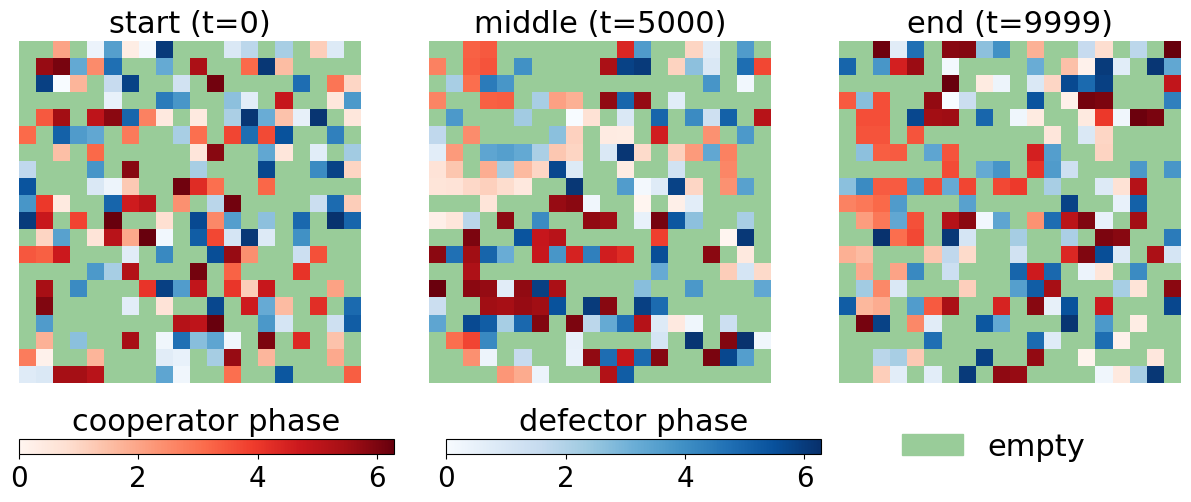

In [7]:
#heatmap with strategies
phaseplotlist = [phase3d[:, :, i] for i in range(repeats)]
stratplotlist = [strat3d[:, :, i] for i in range(repeats)]
print([np.count_nonzero(phase) for phase in phaseplotlist])
print([np.count_nonzero(strat) for strat in stratplotlist])

EMPTY_GREEN = (0.6, 0.8, 0.6)  # RGB tuple used in the heatmap

# Normalize from 0 to 2π
norm_phase = mcolors.Normalize(vmin=0, vmax=2*np.pi)

# Convert to RGB image frames
def create_color_mapped_array(phase, strat):
    combined = np.zeros((phase.shape[0], phase.shape[1], 3))
    red_map = plt.cm.Reds(norm_phase(phase))
    blue_map = plt.cm.Blues(norm_phase(phase))

    combined[strat == -1] = red_map[strat == -1][:, :3]
    combined[strat == -2] = blue_map[strat == -2][:, :3]
    combined[(strat == 0) & (phase == 0)] = EMPTY_GREEN

    return combined

color_mapped_arrays = [
    create_color_mapped_array(phase, strat)
    for phase, strat in zip(phaseplotlist, stratplotlist)
]

# === Plot 3 snapshots: first, middle, last ===
#t_indices = [0, len(color_mapped_arrays) // 2, len(color_mapped_arrays) - 1]
t_indices = [0, 5000, 9999]
titles = ['start', 'middle', 'end']

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Plot snapshots
for ax, idx, title in zip(axs, t_indices, titles):
    ax.imshow(color_mapped_arrays[idx])
    ax.set_title(f'{title} (t={idx})', fontsize = 22)
    ax.axis('off')

# Adjust layout to leave space at the top
fig.subplots_adjust(top=2.5)

# Add horizontal colorbars above the plots
cax_red = fig.add_axes([0.125, 0.82, 0.25, 0.03])   # [left, bottom, width, height]
cax_blue = fig.add_axes([0.41, 0.82, 0.25, 0.03])
cax_green = fig.add_axes([0.75, 0.82, 0.05, 0.03])

# Create colorbars
ColorbarBase(cax_red, cmap=plt.cm.Reds, norm=norm_phase, orientation='horizontal')
cax_red.set_title('cooperator phase', fontsize=22)
cax_red.tick_params(labelsize=20)

ColorbarBase(cax_blue, cmap=plt.cm.Blues, norm=norm_phase, orientation='horizontal')
cax_blue.set_title('defector phase', fontsize=22)
cax_blue.tick_params(labelsize=20)

# Add legend patch for empty (green)
cax_green.axis('off')
green_patch = Patch(color=EMPTY_GREEN, label='empty')
cax_green.legend(handles=[green_patch], loc='center', frameon=False, fontsize=22)



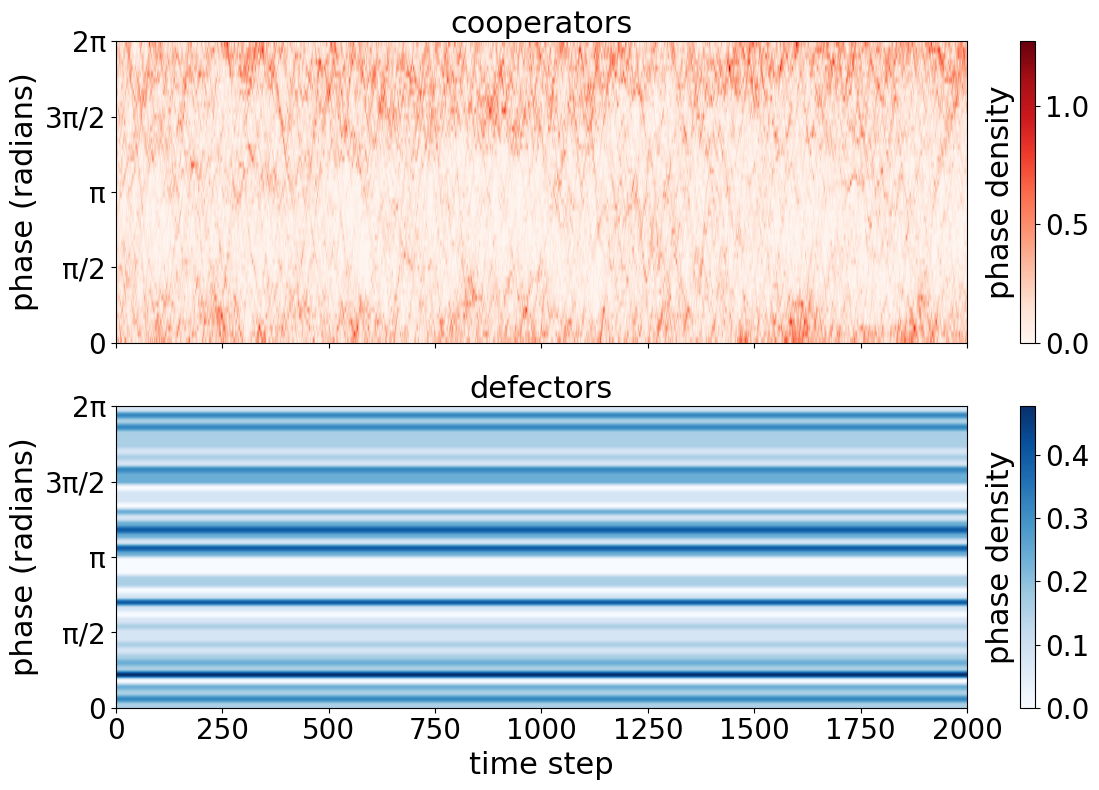

In [8]:
repeats = 2000
phaseplotlist = [phase3d[:, :, i] for i in range(repeats)]
stratplotlist = [strat3d[:, :, i] for i in range(repeats)]

phasedistlist = []
for phase in phaseplotlist:
    filledindices = np.nonzero(phase)
    filledelements = phase[filledindices].tolist()
    phasedistlist.append(filledelements)

stratdistlist = []    
for strat in stratplotlist:
    filledindices = np.nonzero(strat)
    filledelements = strat[filledindices].tolist()
    stratdistlist.append(filledelements)

n_time_steps = len(phasedistlist)
#n_time_steps = 2000
n_bins = 50
phase_bins = np.linspace(0, 2 * np.pi, n_bins + 1)

# Initialize heatmap arrays
heat_coop = np.zeros((n_time_steps, n_bins))
heat_def = np.zeros((n_time_steps, n_bins))

# Fill heatmaps
for i, (phases, strategies) in enumerate(zip(phasedistlist, stratdistlist)):
    phases_coop = [p for p, s in zip(phases, strategies) if s == -1]
    phases_def = [p for p, s in zip(phases, strategies) if s == -2]

    # Compute histograms (density=True normalizes the area under curve)
    if phases_coop:
        hist_coop, _ = np.histogram(phases_coop, bins=phase_bins, density=True)
        heat_coop[i, :] = hist_coop
    if phases_def:
        hist_def, _ = np.histogram(phases_def, bins=phase_bins, density=True)
        heat_def[i, :] = hist_def

# Transpose the heatmaps
heat_coop = heat_coop.T
heat_def = heat_def.T

# New extent: x = time, y = phase
extent = [0, n_time_steps, 0, 2 * np.pi]

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot cooperators
im1 = axs[0].imshow(heat_coop, aspect='auto', origin='lower',
                    extent=extent, cmap='Reds')
axs[0].set_title('cooperators', fontsize = 22)
axs[0].set_ylabel('phase (radians)', fontsize = 22)
#fig.colorbar(im1, ax=axs[0], label='Phase Density')

# Plot defectors
im2 = axs[1].imshow(heat_def, aspect='auto', origin='lower',
                    extent=extent, cmap='Blues')
axs[1].set_title('defectors', fontsize = 22)
axs[1].set_xlabel('time step', fontsize = 22)
axs[1].set_ylabel('phase (radians)', fontsize = 22)
#fig.colorbar(im2, ax=axs[1], label='Phase Density')

# Phase ticks on y-axis in π notation
yticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
ytick_labels = ['0', 'π/2', 'π', '3π/2', '2π']
for ax in axs:
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)
    ax.tick_params(labelsize=20)

cb1 = fig.colorbar(im1, ax=axs[0])
cb1.ax.yaxis.set_label_position('left')
cb1.set_label('phase density', fontsize=22)

cb1.ax.yaxis.tick_right()
cb1.ax.tick_params(labelsize=20)

cb2 = fig.colorbar(im2, ax=axs[1])
cb2.ax.yaxis.set_label_position('left')
cb2.set_label('phase density', fontsize=22)

cb2.ax.yaxis.tick_right()
cb2.ax.tick_params(labelsize=20)


plt.tight_layout()
plt.show()


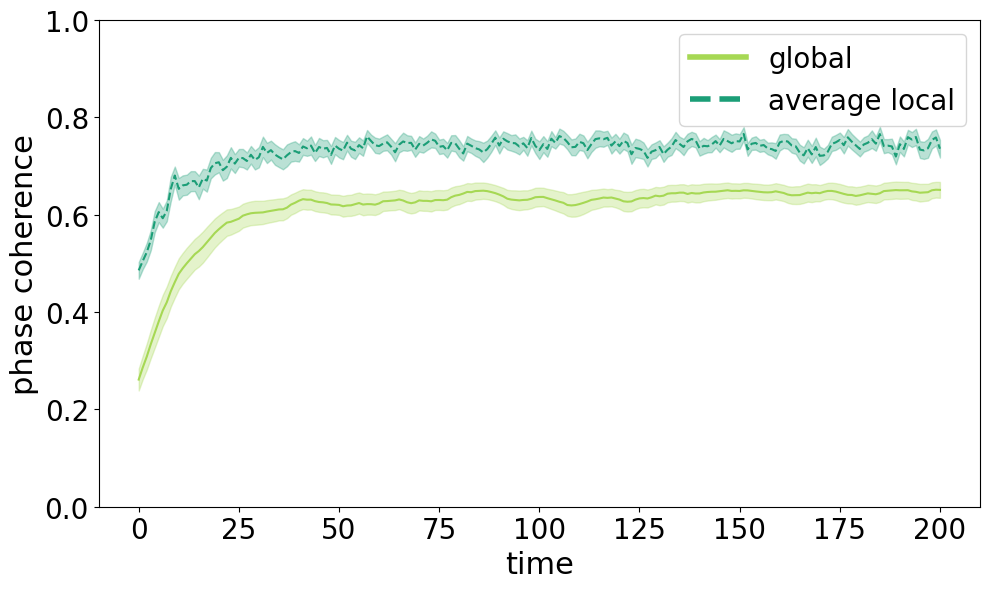

In [30]:
# Parameters
rootN = 5 #no of rows = no of columns (square lattice)
filledprop = 0.5 #proportion of region filled by fireflies
nm = int((rootN ** 2) * filledprop) #number of male fireflies
repeats = 200 #number of iterations over one night
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1 #prob move steepness
rang = 1 #payoff determination range
coopprop = 0.5 #proportion of cooperators
cost = 0.05 #cost of cooperation
num_runs = 30 #number of initializations

g_assorts = np.zeros((num_runs, repeats + 1))  # +1 to include t=0
l_assorts = np.zeros((num_runs, repeats + 1))

for run in range(num_runs):
    firstpos = lattice(rootN, rootN, filledprop) #initial position of male fireflies on lattice
    firstphaselist = phase_list(nm) #initial list of phases of the firelies
    firstphase = phase_arr(firstpos, firstphaselist) #initial phase array
    firststrat = altstrat(firstpos, coopprop) #initial strat array
    firstpay = payoff_arr(firstphase, firststrat, rang, cost) #initial payoff array

    phase3d = np.zeros((rootN, rootN, repeats + 1)) #1 extra just in case
    strat3d = np.zeros((rootN, rootN, repeats + 1))

    phase3d[:, :, 0] = firstphase #initializing first timepoint of phase3d array as initial phase array
    strat3d[:, :, 0] = firststrat #same with strat

    for i in range(repeats): 
        #phase update
        secondphase = kur3(firstphase, firststrat, r, K) #phase array after kuramoto update
        secondpay = payoff_arr(secondphase, firststrat, rang, cost) #payoff array after kuramoto update
        #secondstrat = firststrat #strat remains the same

        #position update
        movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)
        #movphase, movstrat = mov2(secondphase, firststrat, secondpay, cost)

        #after both updates, add timepoint to 3d arrays
        phase3d[:, :, i + 1] = movphase
        #phase3d[:, :, i + 1] = secondphase
        strat3d[:, :, i + 1] = movstrat
        #strat3d[:, :, i + 1] = firststrat

        firstphase = movphase
        #firstphase = secondphase
        firststrat = movstrat
        #firststrat = secondstrat
        firstpay = payoff_arr(firstphase, firststrat, rang, cost)
        
    for t in range(repeats + 1):
        phase_slice = phase3d[:, :, t]
        gcoh_val = globcoh(phase_slice)
        lcoh_val = avgloccoh(phase_slice, rang)
        g_assorts[run, t] = gcoh_val
        l_assorts[run, t] = lcoh_val

# === Compute Mean and Error ===
mean_g = np.mean(g_assorts, axis=0)
mean_l = np.mean(l_assorts, axis=0)
stderr_g = np.std(g_assorts, axis=0)/np.sqrt(num_runs)
stderr_l = np.std(l_assorts, axis=0)/np.sqrt(num_runs)

# === Plotting ===
timepoints = np.arange(repeats + 1)
plt.figure(figsize=(10, 6))

local_color = '#1b9e77'   # darker green
global_color  = '#a6d854'   # lighter green

# Global coherence (violet)
plt.plot(timepoints, mean_g, color= global_color, label='global', linestyle = '-')
plt.fill_between(timepoints, mean_g - stderr_g, mean_g + stderr_g, 
                 color=global_color, alpha=0.3)

# Average local coherence (teal)
plt.plot(timepoints, mean_l, color=local_color, label='average local', linestyle = '--')
plt.fill_between(timepoints, mean_l - stderr_l, mean_l + stderr_l, 
                 color=local_color, alpha=0.3)

plt.xlabel('time', fontsize = 22)
plt.ylabel('phase coherence', fontsize = 22)

# Make legend lines thicker
legend = plt.legend(fontsize=20)
for line in legend.get_lines():
    line.set_linewidth(4)

plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.grid(False)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

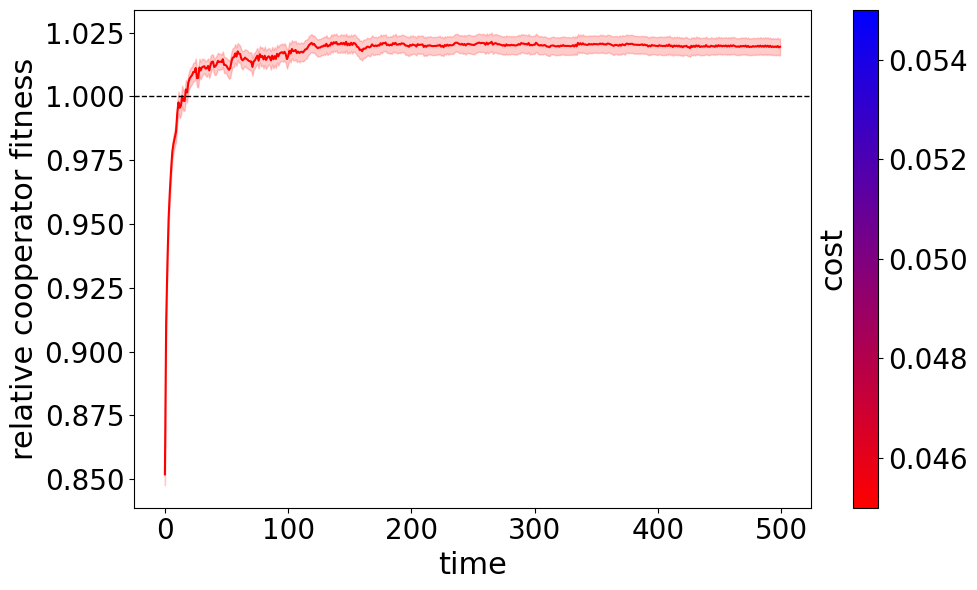

In [ ]:
# --- Parameters ---
rootN = 50
filledprop = 0.5
nm = int((rootN ** 2) * filledprop)
nf = int(nm / 2)
repeats = 500
r = 1
K = 0.5
k = 1000
rang = 1
coopprop = 0.5
cost_values = [0.05]
#cost_values = [0.01, 0.055, 0.075, 0.11]
n_init = 30

# --- Random mating timepoints (same for all inits and costs) ---
#mate_timepoints = np.random.choice(repeats, nf, replace=False)
#mate_timepoints.sort()

# --- Set up plot --

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm

colors = ["red", "purple", "blue"]
cmap = LinearSegmentedColormap.from_list("RedPurpleBlue", colors)
norm = mcolors.Normalize(vmin = min(cost_values), vmax = max(cost_values))

fig, ax = plt.subplots(figsize=(10, 6))

for plot_idx, cost in enumerate(cost_values):
    relcoop_runs = []  # cooperator payoffs over time (n_init x repeats)

    for run in range(n_init):
        # --- Initialization ---
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)
        firststrat = altstrat(firstpos, coopprop)
        firstpay = payoff_arr(firstphase, firststrat, rang, cost)  # assumes cost used in function

        relcoop_payoffs = []

        for i in range(repeats):
            #if i in mate_timepoints:
            #    _ = mate_choice(firstpay, firststrat)

            relcoop = relcooppay2(firstpay, firststrat)
            relcoop_payoffs.append(relcoop)

            secondphase = kur3(firstphase, firststrat, r, K)
            secondpay = payoff_arr(secondphase, firststrat, rang, cost)
            #movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)
            movphase, movstrat = mov2(secondphase, firststrat, secondpay, cost)

            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang, cost)

        relcoop_runs.append(relcoop_payoffs)

    # --- Aggregate results ---
    relcoop_array = np.array(relcoop_runs)
    time = np.arange(repeats)
    relcoop_mean = np.mean(relcoop_array, axis=0)
    relcoop_std = np.std(relcoop_array, axis=0)/np.sqrt(n_init)

    # --- Plot with shaded error bands ---
    c = cmap(norm(cost))
    ax.plot(time, relcoop_mean, color=c, label=f'cost = {cost}')
    ax.fill_between(time, relcoop_mean - relcoop_std, relcoop_mean + relcoop_std, color=c, alpha=0.2)

    # Add horizontal reference line
ax.axhline(y=1, color='black', linestyle='--', linewidth=1, label='no selection')
ax.set_xlabel('time', fontsize = 22)
ax.set_ylabel('relative cooperator fitness', fontsize = 22)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('cost', fontsize = 22)
cbar.ax.tick_params(labelsize = 20)
cbar.ax.yaxis.set_label_position('left')

#plt.ylim(0.96, 1.08)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
#plt.ylim(0.78, 1.08)
plt.tight_layout()
plt.show()


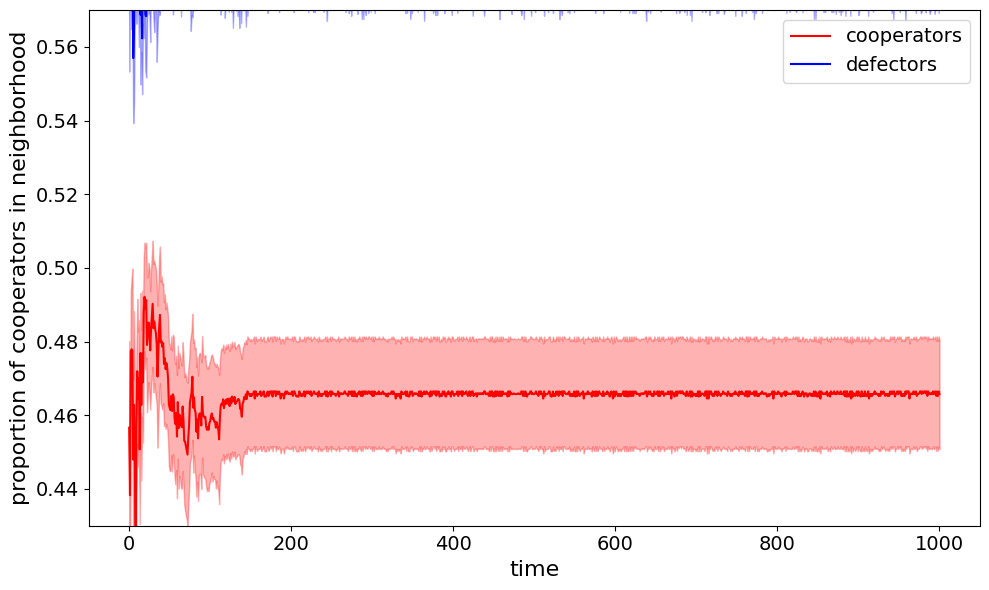

In [ ]:
# Parameters
rootN = 20 #no of rows = no of columns (square lattice)
filledprop = 0.5 #proportion of region filled by fireflies
nm = int((rootN ** 2) * filledprop) #number of male fireflies
repeats = 1000 #number of iterations over one night
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range
coopprop = 0.5 #proportion of cooperators
cost = 0.05 #cost of cooperation
num_runs = 30 #number of initializations

coop_assorts = np.zeros((num_runs, repeats + 1))  # +1 to include t=0
def_assorts = np.zeros((num_runs, repeats + 1))

for run in range(num_runs):
    firstpos = lattice(rootN, rootN, filledprop) #initial position of male fireflies on lattice
    firstphaselist = phase_list(nm) #initial list of phases of the firelies
    firstphase = phase_arr(firstpos, firstphaselist) #initial phase array
    firststrat = altstrat(firstpos, coopprop) #initial strat array
    firstpay = payoff_arr(firstphase, firststrat, rang, cost) #initial payoff array

    phase3d = np.zeros((rootN, rootN, repeats + 1)) #1 extra just in case
    strat3d = np.zeros((rootN, rootN, repeats + 1))

    phase3d[:, :, 0] = firstphase #initializing first timepoint of phase3d array as initial phase array
    strat3d[:, :, 0] = firststrat #same with strat

    for i in range(repeats): 
        #phase update
        secondphase = kur3(firstphase, firststrat, r, K) #phase array after kuramoto update
        secondpay = payoff_arr(secondphase, firststrat, rang, cost) #payoff array after kuramoto update
        #secondstrat = firststrat #strat remains the same

        #position update
        #movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)
        movphase, movstrat = mov2(secondphase, firststrat, secondpay, cost)

        #after both updates, add timepoint to 3d arrays
        phase3d[:, :, i + 1] = movphase
        #phase3d[:, :, i + 1] = secondphase
        strat3d[:, :, i + 1] = movstrat
        #strat3d[:, :, i + 1] = firststrat

        firstphase = movphase
        #firstphase = secondphase
        firststrat = movstrat
        #firststrat = secondstrat
        firstpay = payoff_arr(firstphase, firststrat, rang, cost)
        
    for t in range(repeats + 1):
        strat_slice = strat3d[:, :, t]
        coop_val, def_val = wassort(strat_slice)
        coop_assorts[run, t] = coop_val
        def_assorts[run, t] = def_val

# === Compute Mean and Error ===
mean_coop = np.mean(coop_assorts, axis=0)
mean_def = np.mean(def_assorts, axis=0)
stderr_coop = np.std(coop_assorts, axis=0)/np.sqrt(num_runs)
stderr_def = np.std(def_assorts, axis=0)/np.sqrt(num_runs)

# === Plotting ===
timepoints = np.arange(repeats + 1)
plt.figure(figsize=(10, 6))

# Cooperators (red)
plt.plot(timepoints, mean_coop, color='red', label='cooperators')
plt.fill_between(timepoints, mean_coop - stderr_coop, mean_coop + stderr_coop, 
                 color='red', alpha=0.3)

# Defectors (blue)
plt.plot(timepoints, mean_def, color='blue', label='defectors')
plt.fill_between(timepoints, mean_def - stderr_def, mean_def + stderr_def, 
                 color='blue', alpha=0.3)

plt.xlabel('time', fontsize = 16)
plt.ylabel('proportion of cooperators in neighborhood', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(fontsize = 14)
plt.grid(False)
plt.ylim(0.43, 0.57)
#plt.ylim(0, 1)
plt.tight_layout()
plt.show()

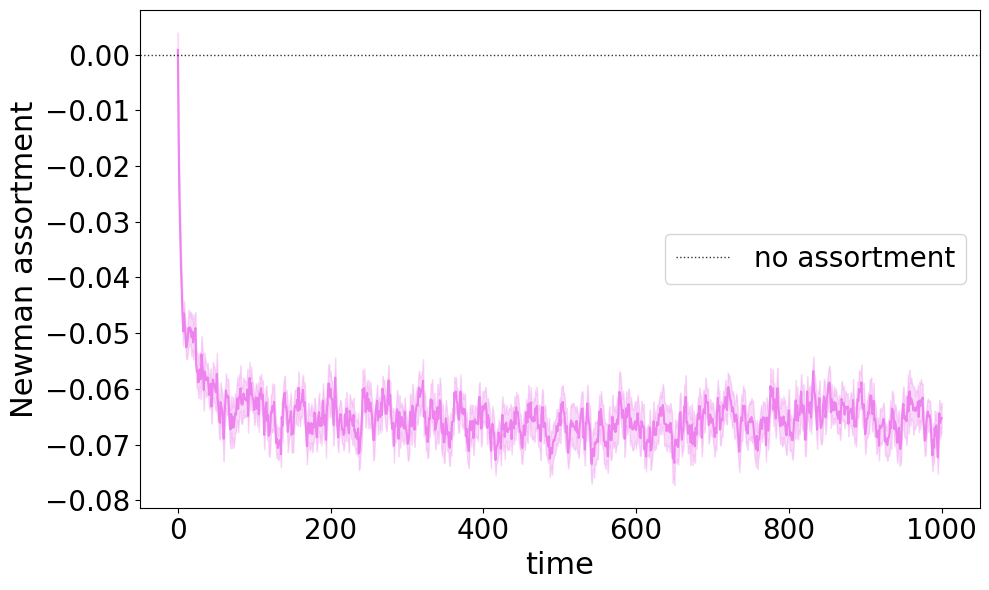

In [3]:
# Parameters
rootN = 50 #no of rows = no of columns (square lattice)
filledprop = 0.5 #proportion of region filled by fireflies
nm = int((rootN ** 2) * filledprop) #number of male fireflies
repeats = 1000 #number of iterations over one night
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range
coopprop = 0.5 #proportion of cooperators
cost = 0.05 #cost of cooperation
num_runs = 30 #number of initializations

assorts = np.zeros((num_runs, repeats + 1))  # +1 to include t=0

for run in range(num_runs):
    firstpos = lattice(rootN, rootN, filledprop) #initial position of male fireflies on lattice
    firstphaselist = phase_list(nm) #initial list of phases of the firelies
    firstphase = phase_arr(firstpos, firstphaselist) #initial phase array
    firststrat = altstrat(firstpos, coopprop) #initial strat array
    firstpay = payoff_arr(firstphase, firststrat, rang, cost) #initial payoff array

    phase3d = np.zeros((rootN, rootN, repeats + 1)) #1 extra just in case
    strat3d = np.zeros((rootN, rootN, repeats + 1))

    phase3d[:, :, 0] = firstphase #initializing first timepoint of phase3d array as initial phase array
    strat3d[:, :, 0] = firststrat #same with strat

    for i in range(repeats): 
        #phase update
        secondphase = kur3(firstphase, firststrat, r, K) #phase array after kuramoto update
        secondpay = payoff_arr(secondphase, firststrat, rang, cost) #payoff array after kuramoto update
        #secondstrat = firststrat #strat remains the same

        #position update
        movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)
        #movphase, movstrat = mov2(secondphase, firststrat, secondpay, cost)

        #after both updates, add timepoint to 3d arrays
        phase3d[:, :, i + 1] = movphase
        #phase3d[:, :, i + 1] = secondphase
        strat3d[:, :, i + 1] = movstrat
        #strat3d[:, :, i + 1] = firststrat

        firstphase = movphase
        #firstphase = secondphase
        firststrat = movstrat
        #firststrat = secondstrat
        firstpay = payoff_arr(firstphase, firststrat, rang, cost)
        
    for t in range(repeats + 1):
        strat_slice = strat3d[:, :, t]
        ass_val = newman(strat_slice)
        assorts[run, t] = ass_val

# === Compute Mean and Error ===
mean_ass = np.mean(assorts, axis=0)
stderr_ass = np.std(assorts, axis=0)/np.sqrt(num_runs)

# === Plotting ===
timepoints = np.arange(repeats + 1)
plt.figure(figsize=(10, 6))

# Cooperators (red)
plt.plot(timepoints, mean_ass, color='violet')
plt.fill_between(timepoints, mean_ass - stderr_ass, mean_ass + stderr_ass, 
                 color='violet', alpha=0.3)

# zero-assortment reference line
plt.axhline(
    y=0,
    color='black',
    linestyle=':',
    linewidth=1,
    alpha=0.8,
    label='no assortment'
)

plt.xlabel('time', fontsize = 22)
plt.ylabel('Newman assortment', fontsize = 22)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.legend(fontsize = 20)
plt.grid(False)
#plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

Generation 0/500
Generation 10/500
Generation 20/500
Generation 30/500
Generation 40/500
Generation 50/500
Generation 60/500
Generation 70/500
Generation 80/500
Generation 90/500
Generation 100/500
Generation 110/500
Generation 120/500
Generation 130/500
Generation 140/500
Generation 150/500
Generation 160/500
Generation 170/500
Generation 180/500
Generation 190/500
Generation 200/500
Generation 210/500
Generation 220/500
Generation 230/500
Generation 240/500
Generation 250/500
Generation 260/500
Generation 270/500
Generation 280/500
Generation 290/500
Generation 300/500
Generation 310/500
Generation 320/500
Generation 330/500
Generation 340/500
Generation 350/500
Generation 360/500
Generation 370/500
Generation 380/500
Generation 390/500
Generation 400/500
Generation 410/500
Generation 420/500
Generation 430/500
Generation 440/500
Generation 450/500
Generation 460/500
Generation 470/500
Generation 480/500
Generation 490/500
Generation 0/500
Generation 10/500
Generation 20/500
Generati

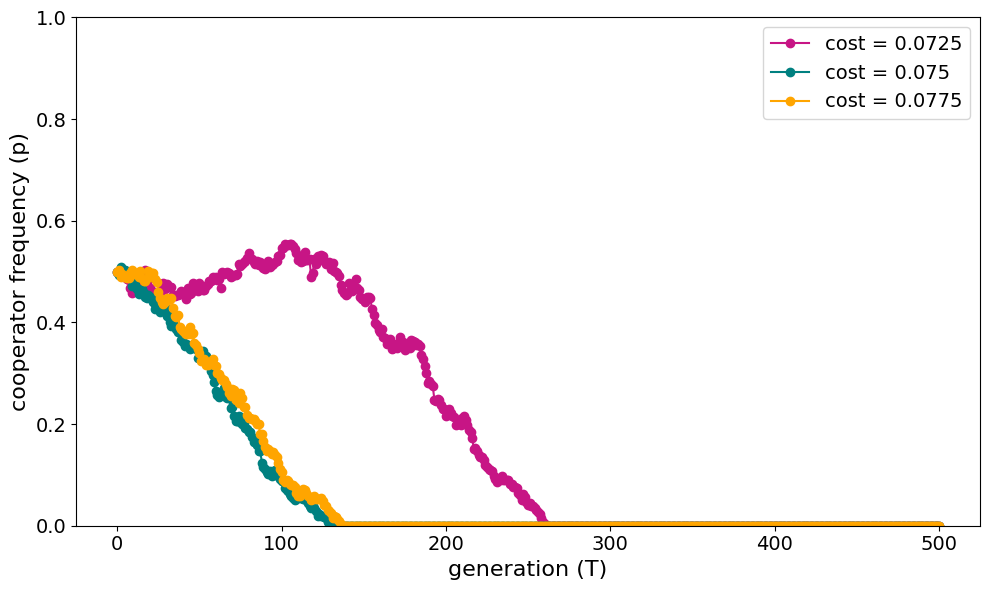

In [ ]:
gen = 500
nights_per_gen = 30
repeats_per_night = 10000
payoff_saturation_timepoint = 75
rootN = 20
filledprop = 0.5
nm = int((rootN ** 2) * filledprop)
nf = int(nm / 2)
r = 1
K = 0.5
k = 1000
rang = 1
start_cfreq = 0.5

cost_values = [0.0725, 0.075, 0.0775]
colors = ['mediumvioletred', 'teal', 'orange']

plt.figure(figsize=(10, 6))

for idx, cost in enumerate(cost_values):
    coopprop_values = [start_cfreq]
    matelist_3d = np.zeros((gen, nights_per_gen, nf))
    
    for i in range(gen):
        if i % 10 == 0:
            print(f"Generation {i}/{gen}")
        # Update coopprop based on previous gen
        if i == 0:
            coopprop = start_cfreq
        else:
            matelist_2d = matelist_3d[i - 1, :, :]
            num_coop = np.count_nonzero(matelist_2d == -1)
            coopprop = num_coop / matelist_2d.size

        for j in range(nights_per_gen):
            init_pos = lattice(rootN, rootN, filledprop)
            init_phase_list = phase_list(nm)
            init_phase = phase_arr(init_pos, init_phase_list)
            init_strat = altstrat(init_pos, coopprop)
            init_pay = payoff_arr(init_phase, init_strat, rang, cost)

            fem_timepoints = np.random.choice(repeats_per_night, nf, replace=False)
            fem_timepoints.sort()
            mate_count = 0
            fem_idx = 0
            next_fem_time = fem_timepoints[fem_idx]

            for t in range(payoff_saturation_timepoint):
                if t == next_fem_time:
                    mate_strat = mate_choice(init_pay, init_strat)
                    matelist_3d[i, j, mate_count] = mate_strat
                    mate_count += 1
                    fem_idx += 1
                    if fem_idx < nf:
                        next_fem_time = fem_timepoints[fem_idx]

                next_phase = kur3(init_phase, init_strat, r, K)
                next_pay = payoff_arr(next_phase, init_strat, rang, cost)
                #mov_phase, mov_strat = mov(next_phase, init_strat, init_pay, next_pay, k)
                mov_phase, mov_strat = mov2(next_phase, init_strat, next_pay, cost)
                init_phase, init_strat = mov_phase, mov_strat
                init_pay = payoff_arr(init_phase, init_strat, rang, cost)

            for t in range(payoff_saturation_timepoint, repeats_per_night):
                if t == next_fem_time:
                    mate_strat = mate_choice(init_pay, init_strat)
                    matelist_3d[i, j, mate_count] = mate_strat
                    mate_count += 1
                    fem_idx += 1
                    if fem_idx < nf:
                        next_fem_time = fem_timepoints[fem_idx]

    # Compute final coopprop time series
    for i in range(gen):
        matelist_2d = matelist_3d[i, :, :]
        num_coop = np.count_nonzero(matelist_2d == -1)
        coopprop = num_coop / matelist_2d.size
        coopprop_values.append(coopprop)

    # Plot this cost’s result
    plt.plot(range(gen + 1), coopprop_values, marker='o', linestyle='-',
             color=colors[idx], label=f'cost = {cost}')

# Plot formatting
plt.xlabel('generation (T)', fontsize = 16)
plt.ylabel('cooperator frequency (p)', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(fontsize = 14)
plt.grid(False)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [8]:
def run_simulation(gen, nights_per_gen, repeats_per_night, payoff_saturation_timepoint,
                   rootN, filledprop, cost, r, K, k, rang, start_cfreq):
    
    nm = int((rootN ** 2) * filledprop)
    nf = int(nm / 2)
    matelist_3d = np.zeros((gen, nights_per_gen, nf))
    
    for i in range(gen):
        if i == 0:
            coopprop = start_cfreq
        else:
            matelist_2d = matelist_3d[i - 1, :, :]
            num_coop = np.count_nonzero(matelist_2d == -1)
            coopprop = num_coop / matelist_2d.size
        
        for j in range(nights_per_gen):
            init_pos = lattice(rootN, rootN, filledprop)
            init_phase_list = phase_list(nm)
            init_phase = phase_arr(init_pos, init_phase_list)
            init_strat = altstrat(init_pos, coopprop)
            init_pay = payoff_arr(init_phase, init_strat, rang, cost)

            fem_timepoints = np.random.choice(repeats_per_night, nf, replace=False)
            fem_timepoints.sort()
            mate_count = 0
            fem_idx = 0
            next_fem_time = fem_timepoints[fem_idx]

            for t in range(payoff_saturation_timepoint):
                if t == next_fem_time:
                    mate_strat = mate_choice(init_pay, init_strat)
                    matelist_3d[i, j, mate_count] = mate_strat
                    mate_count += 1
                    fem_idx += 1
                    if fem_idx < nf:
                        next_fem_time = fem_timepoints[fem_idx]

                next_phase = kur3(init_phase, init_strat, r, K)
                next_pay = payoff_arr(next_phase, init_strat, rang, cost)
                mov_phase, mov_strat = mov(next_phase, init_strat, init_pay, next_pay, k)
                #mov_phase, mov_strat = mov2(next_phase, init_strat, next_pay, cost)
                init_phase = mov_phase
                init_strat = mov_strat
                init_pay = payoff_arr(init_phase, init_strat, rang, cost)

            for t in range(payoff_saturation_timepoint, repeats_per_night):
                if t == next_fem_time:
                    mate_strat = mate_choice(init_pay, init_strat)
                    matelist_3d[i, j, mate_count] = mate_strat
                    mate_count += 1
                    fem_idx += 1
                    if fem_idx < nf:
                        next_fem_time = fem_timepoints[fem_idx]

    # Extract cooperator proportions
    coopprop_values = []
    for i in range(gen):
        matelist_2d = matelist_3d[i, :, :]
        num_coop = np.count_nonzero(matelist_2d == -1)
        tot = matelist_2d.size
        coopprop = num_coop / tot
        coopprop_values.append(coopprop)
    
    coopprop_values.insert(0, start_cfreq)
    return np.array(coopprop_values)


start_cfreq = 0.005, invasion probability = 0.00
start_cfreq = 0.010, invasion probability = 0.00
start_cfreq = 0.015, invasion probability = 0.10
start_cfreq = 0.020, invasion probability = 0.40
start_cfreq = 0.025, invasion probability = 0.60
start_cfreq = 0.030, invasion probability = 0.60
start_cfreq = 0.035, invasion probability = 0.90
start_cfreq = 0.040, invasion probability = 1.00
start_cfreq = 0.045, invasion probability = 1.00
start_cfreq = 0.050, invasion probability = 1.00


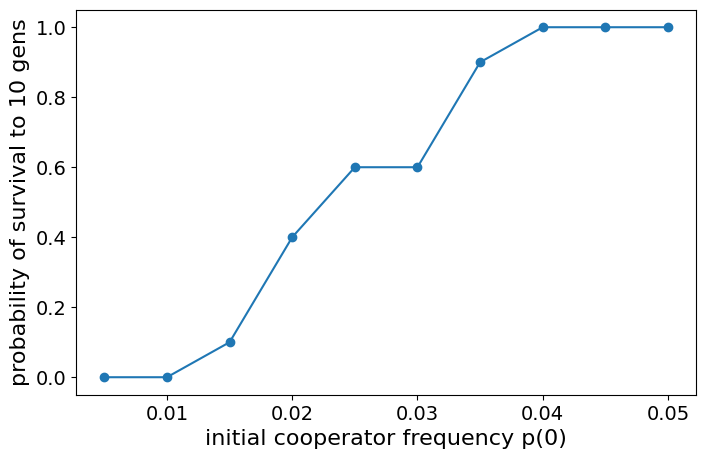

In [6]:
start_freqs = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
num_trials = 10
invasion_probs = []
cost = 0.05

for freq in start_freqs:
    success_count = 0
    for _ in range(num_trials):
        coopprops = run_simulation(
            gen = 10,
            nights_per_gen = 30,
            repeats_per_night = 10000,
            payoff_saturation_timepoint = 75,
            rootN = 20,
            filledprop = 0.5,
            r = 1,
            K = 0.5,
            k = 1000,
            rang = 1,
            start_cfreq = freq
        )
        # Check if cooperation survived (i.e., not zero at the final gen)
        if coopprops[-1] > 0:
            success_count += 1
    invasion_probs.append(success_count / num_trials)
    print(f"start_cfreq = {freq:.3f}, invasion probability = {invasion_probs[-1]:.2f}")

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(start_freqs, invasion_probs, marker='o', linestyle='-')
plt.xlabel('initial cooperator frequency p(0)', fontsize = 16)
plt.ylabel('probability of survival to 10 gens', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(False)
plt.show()


start_cfreq = 0.995, invasion probability = 1.00
start_cfreq = 0.990, invasion probability = 1.00
start_cfreq = 0.985, invasion probability = 1.00
start_cfreq = 0.980, invasion probability = 1.00
start_cfreq = 0.975, invasion probability = 1.00
start_cfreq = 0.970, invasion probability = 1.00
start_cfreq = 0.965, invasion probability = 1.00
start_cfreq = 0.960, invasion probability = 1.00
start_cfreq = 0.955, invasion probability = 1.00
start_cfreq = 0.950, invasion probability = 1.00


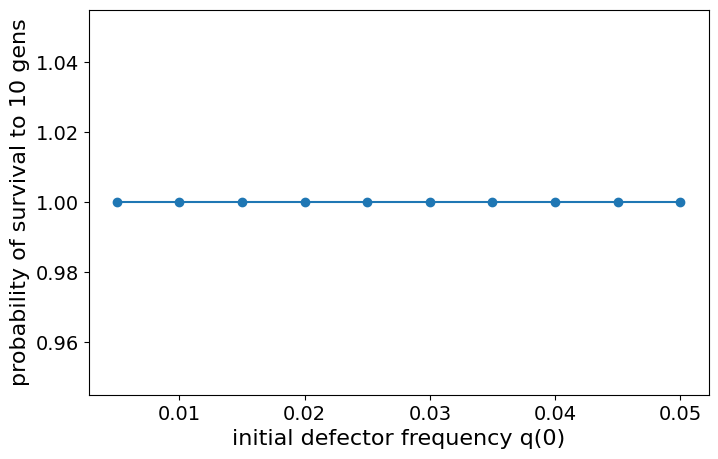

In [7]:
start_freqs = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
start_freqs = [1 - f for f in start_freqs]
num_trials = 3
invasion_probs = []
cost = 0.05

for freq in start_freqs:
    success_count = 0
    for _ in range(num_trials):
        coopprops = run_simulation(
            gen = 5,
            nights_per_gen = 30,
            repeats_per_night = 10000,
            payoff_saturation_timepoint = 75,
            rootN = 20,
            filledprop = 0.5,
            r = 1,
            K = 0.5,
            k = 3,
            rang = 1,
            start_cfreq = freq
        )
        # Check if defection survived (i.e., not zero at the final gen)
        if coopprops[-1] < 1:
            success_count += 1
    invasion_probs.append(success_count / num_trials)
    print(f"start_cfreq = {freq:.3f}, invasion probability = {invasion_probs[-1]:.2f}")

xaxis = [1 - f for f in start_freqs]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(xaxis, invasion_probs, marker='o', linestyle='-')
plt.xlabel('initial defector frequency q(0)', fontsize = 16)
plt.ylabel('probability of survival to 10 gens', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(False)
plt.show()


NaNs in mean_final_rels: 0
NaNs by column (p): [0 0 0 0 0 0 0 0 0 0]
NaNs by row (c): [0 0 0 0 0 0 0 0 0 0]


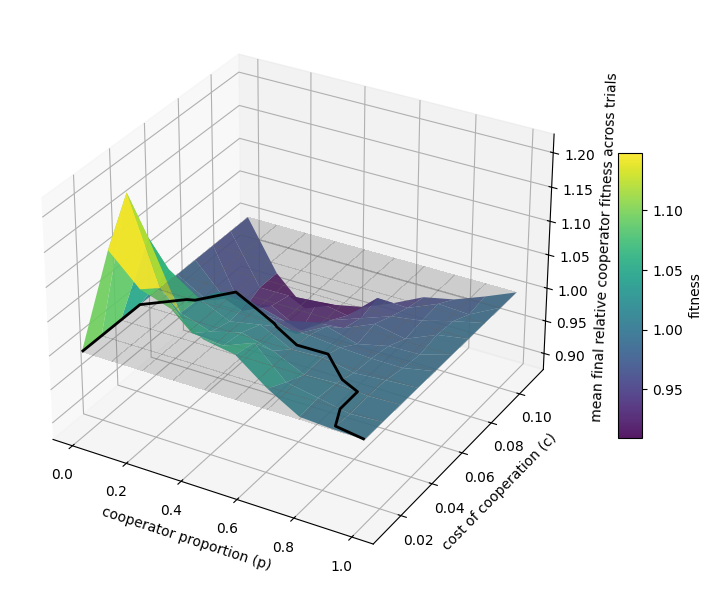

In [ ]:
#plot to make show variation of final relative cooperator fitness with c (cost of cooperation) and p (cooperator proportion)
#parameters
rootN = 20 
filledprop = 0.5 
nm = int((rootN ** 2) * filledprop)
repeats = 200
r = 1
K = 0.5
k = 1000
rang = 1

coopprops = np.linspace(0, 1, 10)
costs = np.linspace(0.01, 0.11, 10)
num_trials = 5 #number of trials for each pair

mean_final_rels = np.zeros((len(costs), len(coopprops)))
se_final_rels = np.zeros((len(costs), len(coopprops)))

for ci, cost in enumerate(costs):
    for pi, coopprop in enumerate(coopprops):

        final_rels_per = []

        for trial in range(num_trials):
            # Reset initial setup for each trial
            firstpos = lattice(rootN, rootN, filledprop)
            firstphaselist = phase_list(nm)
            firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
            firststrat = altstrat(firstpos, coopprop)  # initial strategy array
            firstpay = payoff_arr(firstphase, firststrat, rang, cost)  # initial payoff array

            # 3D arrays for storing phase and strategy over time
            phase3d = np.zeros((rootN, rootN, repeats + 1))
            strat3d = np.zeros((rootN, rootN, repeats + 1))

            # Initialize first time point
            phase3d[:, :, 0] = firstphase
            strat3d[:, :, 0] = firststrat

            firstphase = movphase = firstphase
            firststrat = movstrat = firststrat

            for i in range(repeats):
                # Update phase and position
                secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
                secondpay = payoff_arr(secondphase, firststrat, rang, cost)  # Payoff update with current cost
                movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update
                #movphase, movstrat = mov2(secondphase, firststrat, secondpay, cost)

                phase3d[:, :, i + 1] = movphase
                strat3d[:, :, i + 1] = movstrat

                # Update first phase, strategy, and payoff for the next iteration
                firstphase = movphase
                firststrat = movstrat
                firstpay = payoff_arr(firstphase, firststrat, rang, cost)
            
            final_rel_coop = np.mean([relcooppay2(payoff_arr(phase3d[:, :, i], strat3d[:, :, i], rang, cost), strat3d[:, :, i]) for i in range(payoff_saturation_timepoint, repeats + 1)])
            #final_rel_coop = relcooppay2(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang, cost), strat3d[:, :, -1]) 
            final_rels_per.append(final_rel_coop)

        mean_final_rels[ci, pi] = np.mean(final_rels_per)
        se_final_rels[ci, pi] = np.std(final_rels_per) / np.sqrt(num_trials)  # standard error

from mpl_toolkits.mplot3d import Axes3D

#debugging
print("NaNs in mean_final_rels:", np.isnan(mean_final_rels).sum())
print("NaNs by column (p):", np.isnan(mean_final_rels).sum(axis=0))
print("NaNs by row (c):", np.isnan(mean_final_rels).sum(axis=1))

P, C = np.meshgrid(coopprops, costs)

fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection = '3d')

surf = ax.plot_surface(
    P, C, mean_final_rels,
    cmap = 'viridis',
    edgecolor = 'none',
    alpha = 0.9
)

# Plane z = 1 (no selection)
Z_plane = np.ones_like(P)

ax.plot_surface(
    P, C, Z_plane,
    color='gray',
    alpha=0.25,
    linewidth=0,
    antialiased=False
)

# --- intersection contour ---
ax.contour(
    P, C, mean_final_rels,
    levels=[1.0],
    colors='black',
    linewidths=2
)

ax.set_xlabel('cooperator proportion (p)')
ax.set_ylabel('cost of cooperation (c)')
ax.set_zlabel('mean final relative cooperator fitness across trials')

fig.colorbar(surf, ax = ax, shrink = 0.5, aspect = 12, label = 'fitness')
plt.tight_layout()
plt.show()

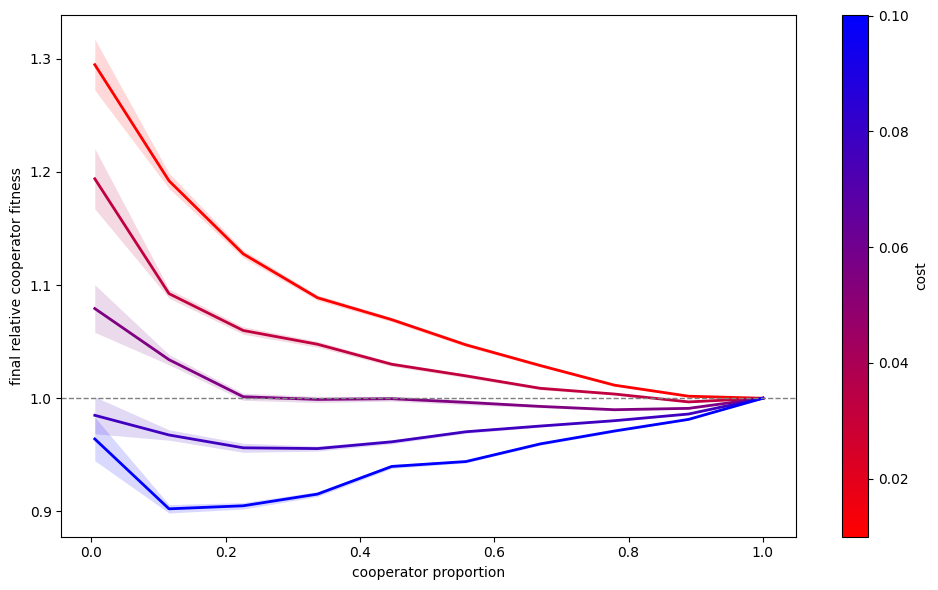

In [30]:
#plot to get variation of final relcoop with coopprop, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
filledprop = 0.5  # proportion of the region filled by fireflies
nm = int((rootN ** 2) * filledprop)  # number of male fireflies
repeats = 200  # number of iterations over one night

# Initial setup for firefly positions and phases
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range
payoff_saturation_timepoint = 75

# Range of costs to analyze
costs = np.linspace(0.01, 0.10, 5)
coopprops = np.linspace(0.005, 1, 10) #range of coopprops from 0.005 to 1
num_trials = 30  # number of trials for each cost

#colormap setup
colors = ["red", "purple", "blue"]
cmap = LinearSegmentedColormap.from_list("RedPurpleBlue", colors)
norm = mcolors.Normalize(vmin = min(costs), vmax = max(costs))

plt.figure(figsize = (10, 6))

for cost in costs:
    mean_final_rels = []
    se_final_rels = []

    for coopprop in coopprops:
        final_rels_per_coopprop = []  # to store final std devs for all trials of a particular cost

        for trial in range(num_trials):
            # Reset initial setup for each trial
            firstpos = lattice(rootN, rootN, filledprop)
            firstphaselist = phase_list(nm)
            firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
            firststrat = altstrat(firstpos, coopprop)  # initial strategy array
            firstpay = payoff_arr(firstphase, firststrat, rang, cost)  # initial payoff array

            # 3D arrays for storing phase and strategy over time
            phase3d = np.zeros((rootN, rootN, repeats + 1))
            strat3d = np.zeros((rootN, rootN, repeats + 1))

            # Initialize first time point
            phase3d[:, :, 0] = firstphase
            strat3d[:, :, 0] = firststrat

            #firstphase = movphase = firstphase
            #firststrat = movstrat = firststrat

            for i in range(repeats):
                # Update phase and strategy
                secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
                secondpay = payoff_arr(secondphase, firststrat, rang, cost)  # Payoff update with current cost
                movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update
                #movphase, movstrat = mov2(secondphase, firststrat, secondpay, cost)

                # Store updates in 3D arrays
                phase3d[:, :, i + 1] = movphase
                strat3d[:, :, i + 1] = movstrat

                # Update first phase, strategy, and payoff for the next iteration
                firstphase = movphase
                firststrat = movstrat
                firstpay = payoff_arr(firstphase, firststrat, rang, cost)

            # Compute the standard deviation of the final phase array for this trial
            final_rel_coop = np.mean([relcooppay2(payoff_arr(phase3d[:, :, i], strat3d[:, :, i], rang, cost), strat3d[:, :, i]) for i in range(payoff_saturation_timepoint, repeats + 1)])
            #final_rel_coop = relcooppay2(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang, cost), strat3d[:, :, -1])  # standard deviation of final phases
            final_rels_per_coopprop.append(final_rel_coop)
        
        # Store the results
        final_rels_per_coopprop = np.array(final_rels_per_coopprop)
        mean_final_rels.append(final_rels_per_coopprop.mean())
        se = (final_rels_per_coopprop.std(ddof=1)) / np.sqrt(num_trials)
        se_final_rels.append(se)

    mean_final_rels = np.array(mean_final_rels)
    se_final_rels = np.array(se_final_rels)

    color = cmap(norm(cost))

    plt.plot(coopprops, mean_final_rels, color = color, linewidth = 2)
    plt.fill_between(coopprops, mean_final_rels - se_final_rels, mean_final_rels + se_final_rels, color = color, alpha = 0.15, linewidth = 0)

plt.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='no selection')
plt.xlabel('cooperator proportion')
plt.ylabel('final relative cooperator fitness')

#plt.yscale('log')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax = plt.gca())
cbar.set_label('cost')

plt.tight_layout()
plt.show()

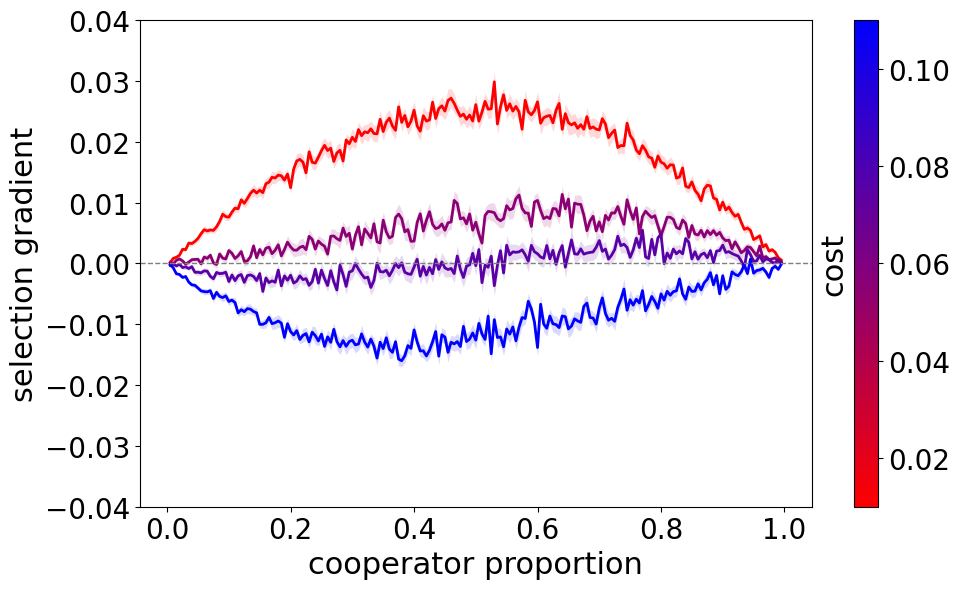

In [39]:
#plot to get variation of final relcoop with coopprop, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
filledprop = 0.5  # proportion of the region filled by fireflies
nm = int((rootN ** 2) * filledprop)  # number of male fireflies
repeats = 200  # number of iterations over one night

# Initial setup for firefly positions and phases
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range
payoff_saturation_timepoint = 75

# Range of costs to analyze
#costs = np.linspace(0.01, 0.10, 5)
costs = [0.01, 0.055, 0.075, 0.11]

start = 0.005
end = 0.995
step = 0.005

num = int(round((end - start) / step)) + 1
coopprops = np.linspace(start, end, num)
num_trials = 30  # number of trials for each cost

#colormap setup
colors = ["red", "purple", "blue"]
cmap = LinearSegmentedColormap.from_list("RedPurpleBlue", colors)
norm = mcolors.Normalize(vmin = min(costs), vmax = max(costs))

plt.figure(figsize = (10, 6))

for cost in costs:
    mean_final_rels = []
    se_final_rels = []

    for coopprop in coopprops:
        final_rels_per_coopprop = []  # to store final std devs for all trials of a particular cost

        for trial in range(num_trials):
            # Reset initial setup for each trial
            firstpos = lattice(rootN, rootN, filledprop)
            firstphaselist = phase_list(nm)
            firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
            firststrat = altstrat(firstpos, coopprop)  # initial strategy array
            firstpay = payoff_arr(firstphase, firststrat, rang, cost)  # initial payoff array

            # 3D arrays for storing phase and strategy over time
            phase3d = np.zeros((rootN, rootN, repeats + 1))
            strat3d = np.zeros((rootN, rootN, repeats + 1))

            # Initialize first time point
            phase3d[:, :, 0] = firstphase
            strat3d[:, :, 0] = firststrat

            #firstphase = movphase = firstphase
            #firststrat = movstrat = firststrat

            for i in range(repeats):
                # Update phase and strategy
                secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
                secondpay = payoff_arr(secondphase, firststrat, rang, cost)  # Payoff update with current cost
                #movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update
                movphase, movstrat = mov2(secondphase, firststrat, secondpay, cost)

                # Store updates in 3D arrays
                phase3d[:, :, i + 1] = movphase
                strat3d[:, :, i + 1] = movstrat

                # Update first phase, strategy, and payoff for the next iteration
                firstphase = movphase
                firststrat = movstrat
                firstpay = payoff_arr(firstphase, firststrat, rang, cost)

            # Compute the standard deviation of the final phase array for this trial
            final_rel_coop = np.mean([relcooppay2(payoff_arr(phase3d[:, :, i], strat3d[:, :, i], rang, cost), strat3d[:, :, i]) for i in range(payoff_saturation_timepoint, repeats + 1)])
            #final_rel_coop = relcooppay2(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang, cost), strat3d[:, :, -1])  # standard deviation of final phases
            final_rels_per_coopprop.append(final_rel_coop)
        
        # Store the results
        final_rels_per_coopprop = np.array(final_rels_per_coopprop)
        mean_final_rels.append(final_rels_per_coopprop.mean())
        se = (final_rels_per_coopprop.std(ddof=1)) / np.sqrt(num_trials)
        se_final_rels.append(se)

    R = np.array(mean_final_rels)
    SE_R = np.array(se_final_rels)
    p = coopprops

    delta_p_det = p * (R - 1)
    se_delta_p = p * SE_R

    color = cmap(norm(cost))

    plt.plot(p, delta_p_det, color = color, linewidth = 2)
    plt.fill_between(p, delta_p_det - se_delta_p, delta_p_det + se_delta_p, color = color, alpha = 0.15, linewidth = 0)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1, label='no selection')
plt.xlabel('cooperator proportion', fontsize = 22)
plt.ylabel('selection gradient', fontsize = 22)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.ylim(-0.04, 0.04)

#plt.yscale('log')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax = plt.gca())
cbar.set_label('cost', fontsize = 22)
cbar.ax.tick_params(labelsize = 20)
cbar.ax.yaxis.set_label_position('left')

plt.tight_layout()
plt.show()

NaNs in mean_final_rels: 0
NaNs by column (p): [0 0 0 0 0 0 0 0 0 0]
NaNs by row (c): [0 0 0 0 0 0 0 0 0]


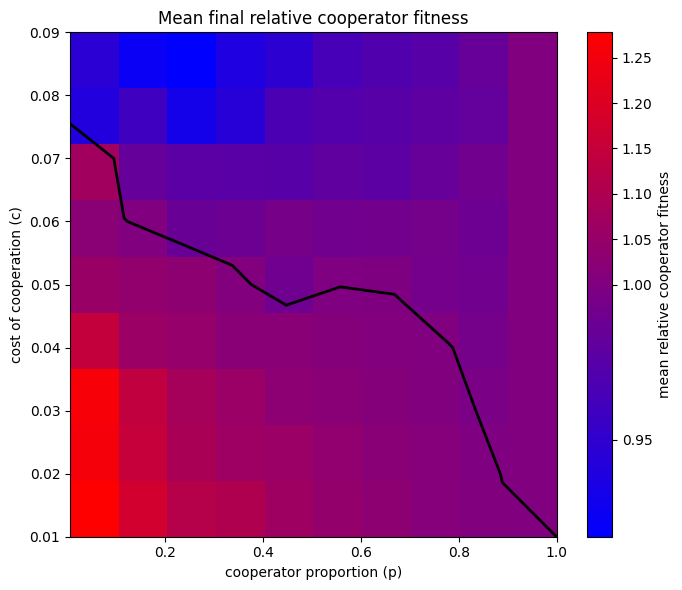

In [3]:
#plot to make show variation of final relative cooperator fitness with c (cost of cooperation) and p (cooperator proportion)
#parameters
rootN = 20 
filledprop = 0.5 
nm = int((rootN ** 2) * filledprop)
repeats = 200
r = 1
K = 0.5
k = 1000
rang = 1
payoff_saturation_timepoint = 75

coopprops = np.linspace(0.005, 1, 10)
costs = np.linspace(0.01, 0.09, 9)
num_trials = 5 #number of trials for each pair

mean_final_rels = np.zeros((len(costs), len(coopprops)))
se_final_rels = np.zeros((len(costs), len(coopprops)))

for ci, cost in enumerate(costs):
    for pi, coopprop in enumerate(coopprops):

        final_rels_per = []

        for trial in range(num_trials):
            # Reset initial setup for each trial
            firstpos = lattice(rootN, rootN, filledprop)
            firstphaselist = phase_list(nm)
            firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
            firststrat = altstrat(firstpos, coopprop)  # initial strategy array
            firstpay = payoff_arr(firstphase, firststrat, rang, cost)  # initial payoff array

            # 3D arrays for storing phase and strategy over time
            phase3d = np.zeros((rootN, rootN, repeats + 1))
            strat3d = np.zeros((rootN, rootN, repeats + 1))

            # Initialize first time point
            phase3d[:, :, 0] = firstphase
            strat3d[:, :, 0] = firststrat

            firstphase = movphase = firstphase
            firststrat = movstrat = firststrat

            for i in range(repeats):
                # Update phase and position
                secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
                secondpay = payoff_arr(secondphase, firststrat, rang, cost)  # Payoff update with current cost
                movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update
                #movphase, movstrat = mov2(secondphase, firststrat, secondpay, cost)

                phase3d[:, :, i + 1] = movphase
                strat3d[:, :, i + 1] = movstrat

                # Update first phase, strategy, and payoff for the next iteration
                firstphase = movphase
                firststrat = movstrat
                firstpay = payoff_arr(firstphase, firststrat, rang, cost)
            
            final_rel_coop = np.mean([relcooppay2(payoff_arr(phase3d[:, :, i], strat3d[:, :, i], rang, cost), strat3d[:, :, i]) for i in range(payoff_saturation_timepoint, repeats + 1)])
            #final_rel_coop = relcooppay2(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang, cost), strat3d[:, :, -1]) 
            final_rels_per.append(final_rel_coop)

        mean_final_rels[ci, pi] = np.mean(final_rels_per)
        se_final_rels[ci, pi] = np.std(final_rels_per) / np.sqrt(num_trials)  # standard error

#debugging
print("NaNs in mean_final_rels:", np.isnan(mean_final_rels).sum())
print("NaNs by column (p):", np.isnan(mean_final_rels).sum(axis=0))
print("NaNs by row (c):", np.isnan(mean_final_rels).sum(axis=1))

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

bpr = LinearSegmentedColormap.from_list(
    'blue_purple_red',
    ['blue', 'purple', 'red']
)

vmin = np.nanmin(mean_final_rels)
vmax = np.nanmax(mean_final_rels)

norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    mean_final_rels,
    origin='lower',
    aspect='auto',
    cmap=bpr,
    norm=norm,
    extent=[
        coopprops.min(), coopprops.max(),
        costs.min(), costs.max()
    ]
)

# Contour with meshgrid
P, C = np.meshgrid(coopprops, costs)
ax.contour(P, C, mean_final_rels, levels=[1.0], colors='black', linewidths=2)


ax.set_xlabel('cooperator proportion (p)')
ax.set_ylabel('cost of cooperation (c)')
ax.set_title('Mean final relative cooperator fitness')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('mean relative cooperator fitness')

plt.tight_layout()
plt.show()


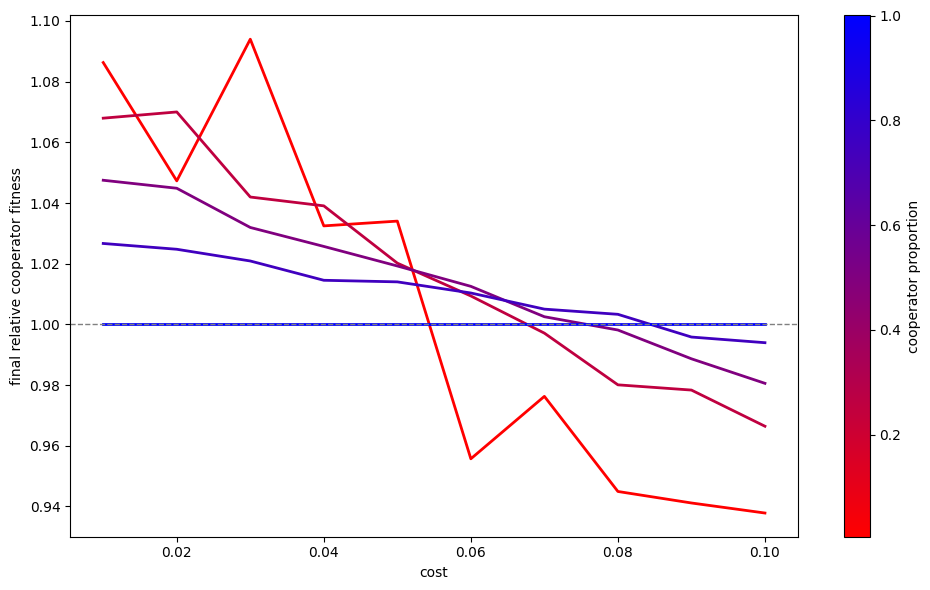

In [ ]:
#plot to get variation of final relcoop with coopprop, movement rule 1
rootN = 20  # number of rows and columns (square lattice)
filledprop = 0.5  # proportion of the region filled by fireflies
nm = int((rootN ** 2) * filledprop)  # number of male fireflies
repeats = 200  # number of iterations over one night

# Initial setup for firefly positions and phases
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range
payoff_saturation_timepoint = 75

# Range of costs to analyze
costs = np.linspace(0.01, 0.10, 10)
coopprops = cprop_valid(nm, 5) #set of coopprops
num_trials = 30  # number of trials for each coopprop

#colormap setup
colors = ["red", "purple", "blue"]
cmap = LinearSegmentedColormap.from_list("RedPurpleBlue", colors)
norm = mcolors.Normalize(vmin = min(coopprops), vmax = max(coopprops))

plt.figure(figsize = (10, 6))

for coopprop in coopprops:
    mean_final_rels = []

    for cost in costs:
        final_rels_per_cost = []  # to store final std devs for all trials of a particular cost

        for trial in range(num_trials):
            # Reset initial setup for each trial
            firstpos = lattice(rootN, rootN, filledprop)
            firstphaselist = phase_list(nm)
            firstphase = phase_arr(firstpos, firstphaselist)  # initial phase array
            firststrat = altstrat(firstpos, coopprop)  # initial strategy array
            firstpay = payoff_arr(firstphase, firststrat, rang, cost)  # initial payoff array

            # 3D arrays for storing phase and strategy over time
            phase3d = np.zeros((rootN, rootN, repeats + 1))
            strat3d = np.zeros((rootN, rootN, repeats + 1))

            # Initialize first time point
            phase3d[:, :, 0] = firstphase
            strat3d[:, :, 0] = firststrat

            #firstphase = movphase = firstphase
            #firststrat = movstrat = firststrat

            for i in range(repeats):
                # Update phase and strategy
                secondphase = kur3(firstphase, firststrat, r, K)  # Kuramoto update
                secondpay = payoff_arr(secondphase, firststrat, rang, cost)  # Payoff update with current cost
                #movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)  # Position update
                movphase, movstrat = mov2(secondphase, firststrat, secondpay, cost)

                # Store updates in 3D arrays
                phase3d[:, :, i + 1] = movphase
                strat3d[:, :, i + 1] = movstrat

                # Update first phase, strategy, and payoff for the next iteration
                firstphase = movphase
                firststrat = movstrat
                firstpay = payoff_arr(firstphase, firststrat, rang, cost)

            # Compute the standard deviation of the final phase array for this trial
            final_rel_coop = np.mean([relcooppay2(payoff_arr(phase3d[:, :, i], strat3d[:, :, i], rang, cost), strat3d[:, :, i]) for i in range(payoff_saturation_timepoint, repeats + 1)])
            #final_rel_coop = relcooppay2(payoff_arr(phase3d[:, :, -1], strat3d[:, :, -1], rang, cost), strat3d[:, :, -1])  # standard deviation of final phases
            final_rels_per_cost.append(final_rel_coop)
        
        # Store the results
        mean_final_rels.append(np.mean(final_rels_per_cost))

    mean_final_rels = np.array(mean_final_rels)

    plt.plot(costs, mean_final_rels, color = cmap(norm(coopprop)), linewidth = 2)


plt.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='no selection')
plt.xlabel('cost')
plt.ylabel('final relative cooperator fitness')

#plt.yscale('log')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax = plt.gca())
cbar.set_label('cooperator proportion')

plt.tight_layout()
plt.show()

In [11]:
def run_simulation(gen, nights_per_gen, repeats_per_night, payoff_saturation_timepoint,
                   rootN, filledprop, cost, r, K, k, rang, start_cfreq):
    
    nm = int((rootN ** 2) * filledprop)
    nf = int(nm / 2)
    matelist_3d = np.zeros((gen, nights_per_gen, nf))
    
    for i in range(gen):
        if i == 0:
            coopprop = start_cfreq
        else:
            matelist_2d = matelist_3d[i - 1, :, :]
            num_coop = np.count_nonzero(matelist_2d == -1)
            coopprop = num_coop / matelist_2d.size
        
        for j in range(nights_per_gen):
            init_pos = lattice(rootN, rootN, filledprop)
            init_phase_list = phase_list(nm)
            init_phase = phase_arr(init_pos, init_phase_list)
            init_strat = altstrat(init_pos, coopprop)
            init_pay = payoff_arr(init_phase, init_strat, rang, cost)

            fem_timepoints = np.random.choice(repeats_per_night, nf, replace=False)
            fem_timepoints.sort()
            mate_count = 0
            fem_idx = 0
            next_fem_time = fem_timepoints[fem_idx]

            for t in range(payoff_saturation_timepoint):
                if t == next_fem_time:
                    mate_strat = mate_choice(init_pay, init_strat)
                    matelist_3d[i, j, mate_count] = mate_strat
                    mate_count += 1
                    fem_idx += 1
                    if fem_idx < nf:
                        next_fem_time = fem_timepoints[fem_idx]

                next_phase = kur3(init_phase, init_strat, r, K)
                next_pay = payoff_arr(next_phase, init_strat, rang, cost)
                #mov_phase, mov_strat = mov(next_phase, init_strat, init_pay, next_pay, k)
                mov_phase, mov_strat = mov2(next_phase, init_strat, next_pay, cost)
                init_phase = mov_phase
                init_strat = mov_strat
                init_pay = payoff_arr(init_phase, init_strat, rang, cost)

            for t in range(payoff_saturation_timepoint, repeats_per_night):
                if t == next_fem_time:
                    mate_strat = mate_choice(init_pay, init_strat)
                    matelist_3d[i, j, mate_count] = mate_strat
                    mate_count += 1
                    fem_idx += 1
                    if fem_idx < nf:
                        next_fem_time = fem_timepoints[fem_idx]

    # Extract cooperator proportions
    coopprop_values = []
    for i in range(gen):
        matelist_2d = matelist_3d[i, :, :]
        num_coop = np.count_nonzero(matelist_2d == -1)
        tot = matelist_2d.size
        coopprop = num_coop / tot
        coopprop_values.append(coopprop)
    
    coopprop_values.insert(0, start_cfreq)
    return np.array(coopprop_values)


In [ ]:
start_freqs_coop = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
num_trials = 10
coop_invasion_probs = []

for freq in start_freqs_coop:
    success_count = 0
    for _ in range(num_trials):
        coopprops = run_simulation(
            gen = 5,
            nights_per_gen = 30,
            repeats_per_night = 10000,
            payoff_saturation_timepoint = 75,
            rootN = 20,
            filledprop = 0.5,
            cost = 0.05,
            r = 1,
            K = 0.5,
            k = 1000,
            rang = 1,
            start_cfreq = freq
        )
        # Check if cooperation survived (i.e., not zero at the final gen)
        if coopprops[-1] > 0:
            success_count += 1
    coop_invasion_probs.append(success_count / num_trials)
    print(f"start_cfreq = {freq:.3f}, invasion probability = {coop_invasion_probs[-1]:.2f}")

start_cfreq = 0.005, invasion probability = 0.90
start_cfreq = 0.010, invasion probability = 1.00
start_cfreq = 0.015, invasion probability = 1.00
start_cfreq = 0.020, invasion probability = 1.00
start_cfreq = 0.025, invasion probability = 1.00
start_cfreq = 0.030, invasion probability = 1.00
start_cfreq = 0.035, invasion probability = 1.00
start_cfreq = 0.040, invasion probability = 1.00
start_cfreq = 0.045, invasion probability = 1.00
start_cfreq = 0.050, invasion probability = 1.00


In [ ]:
start_freqs_def = [1 - f for f in start_freqs_coop]
num_trials = 5
def_invasion_probs = []

for freq in start_freqs_def:
    success_count = 0
    for _ in range(num_trials):
        coopprops = run_simulation(
            gen = 5,
            nights_per_gen = 30,
            repeats_per_night = 10000,
            payoff_saturation_timepoint = 75,
            rootN = 20,
            filledprop = 0.5,
            cost = 0.05,
            r = 1,
            K = 0.5,
            k = 1000,
            rang = 1,
            start_cfreq = freq
        )
        # Check if defection survived (i.e., not zero at the final gen)
        if coopprops[-1] < 1:
            success_count += 1
    def_invasion_probs.append(success_count / num_trials)
    print(f"start_cfreq = {freq:.3f}, invasion probability = {def_invasion_probs[-1]:.2f}")


start_cfreq = 0.995, invasion probability = 1.00
start_cfreq = 0.990, invasion probability = 1.00
start_cfreq = 0.985, invasion probability = 1.00
start_cfreq = 0.980, invasion probability = 1.00
start_cfreq = 0.975, invasion probability = 1.00
start_cfreq = 0.970, invasion probability = 1.00
start_cfreq = 0.965, invasion probability = 1.00
start_cfreq = 0.960, invasion probability = 1.00
start_cfreq = 0.955, invasion probability = 1.00
start_cfreq = 0.950, invasion probability = 1.00


In [ ]:
x_def = [1 - f for f in start_freqs_def]  # = original small frequencies
x_coop = start_freqs_coop

plt.figure(figsize=(8, 5))

plt.plot(
    x_coop,
    coop_invasion_probs,
    marker='o',
    linestyle='-',
    color='red',
    label='cooperator',
    linewidth = 3
)

plt.plot(
    x_def,
    def_invasion_probs,
    marker='o',
    linestyle='-',
    color='blue',
    label='defector',
    linewidth = 2
)

plt.xlabel('initial mutant frequency', fontsize=22)
plt.ylabel('probability of survival', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(False)

plt.show()

NameError: name 'start_freqs_def' is not defined